## 0. Import thư viện và cấu hình

In [40]:
import os
import pickle
import time
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import binomtest

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score, log_loss
)

from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
print('Đã tải xong tất cả thư viện cần thiết.')

# Thiết lập đường dẫn và đọc file pickle đã xử lý
_notebook_dir  = os.path.abspath('')
BASE_PATH      = os.path.abspath(os.path.join(_notebook_dir, '..', '..'))
PROC_DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
FIG_PATH       = os.path.join(BASE_PATH, 'report', 'figures', 'lr')
os.makedirs(FIG_PATH, exist_ok=True)

PKL_PATH = os.path.join(PROC_DATA_PATH, 'processed_data.pkl')

with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

FEATURE_NAMES = data['X_train'].columns.tolist()

X_train = data['X_train'].values.astype(np.float64)
y_train = data['y_train'].values.astype(int)
X_val   = data['X_val'].values.astype(np.float64)
y_val   = data['y_val'].values.astype(int)
X_test  = data['X_test'].values.astype(np.float64)
y_test  = data['y_test'].values.astype(int)
CLASS_WEIGHTS = data['class_weights']  # {0: w0, 1: w1}

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print(f'Số đặc trưng: {X_train.shape[1]}')
print(f'Class weights: {CLASS_WEIGHTS}')

Đã tải xong tất cả thư viện cần thiết.
Train : (90916, 24)
Val   : (12988, 24)
Test  : (25976, 24)
Số đặc trưng: 24
Class weights: {0: 0.8823540829596848, 1: 1.153844201335127}


## 1. Lý thuyết Linear Discriminant Analysis (LDA) và Quadratic Discriminant Analysis (QDA)

### 1.1 Mô hình sinh Gaussian trong phân lớp

Trong mô hình sinh (generative model), ta giả sử dữ liệu đặc trưng $ x $ của mỗi lớp $ C_k $ tuân theo phân phối Gaussian đa biến:

$$
p(x \mid C_k) = \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

Trong đó:
- $ \mu_k $: vector kì vọng của lớp $ k $  
- $ \Sigma_k $: ma trận hiệp phương sai của lớp $ k $

Ngoài ra, mỗi lớp có xác xuất tiên nghiệm: 
$$
\pi_k = P(C_k)
$$

Để xây dựng mô hình, các tham số này được ước lượng dựa trên dữ liệu huấn luyện thông qua phương pháp cực đại hóa khả năng (Maximum Likelihood Estimation - MLE):

Vector trung bình ước lượng: $ \hat{\mu}_k = \frac{1}{N_k} \sum_{n \in C_k} x_n $

Ma trận hiệp phương sai ước lượng: $ \hat{\Sigma}_k = \frac{1}{N_k} \sum_{n \in C_k} (x_n - \hat{\mu}_k)(x_n - \hat{\mu}_k)^T $


## 1.2 Mô hình Linear Discriminant Analysis (LDA)

LDA giả định rằng tất cả các lớp chia sẻ cùng một ma trận hiệp phương sai, tức là $\Sigma_0 = \Sigma_1 =....= \Sigma$ 

Khi đó, ma trận hiệp phương sai chung được ước lượng như sau:

$$
\hat{\Sigma} = \sum_{k} \frac{N_k}{N} \hat{\Sigma}_k
$$

Áp dụng định lý Bayes: 
$$
p(C_k \mid x) \propto p(x \mid C_k)\, p(C_k)
$$

Lấy log và rút gọn, ta được phân biệt của LDA được định nghĩa như sau:

$$
\delta_k(x) = x^T \Sigma^{-1} \mu_k 
- \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k 
+ \log \pi_k
$$

trong đó $ \pi_k = P(C_k) $ là xác suất tiên nghiệm của lớp.

### Nhận xét:
Vì LDA sử dụng một ma trận hiệp phương sai cho mọi lớp, các hạng tử bậc hai trong log-likelihood bị triệt tiêu, dẫn đến **biên quyết định giữa các lớp có dạng tuyến tính**. Điều này giúp mô hình ổn định nhưng sẽ bị giới hạn khi dữ liệu có cấu trúc phức tạp.


## 1.3 Mô hình Quadratic Discriminant Analysis (QDA)

QDA là sự mở rộng của LDA bằng cách cho phép mỗi lớp $C_k$ có hiệp phương sai riêng $\Sigma_k$.

$$
p(x \mid C_k) = \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

Khi đó, hàm phân biệt QDA giữ lại thành phần bậc 2:

$$
\delta_k(x) = 
-\frac{1}{2} \log |\Sigma_k|
- \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k)
+ \log \pi_k
$$

### Nhận xét:
Với các thành phần bậc 2 giúp QDA tạo ra các **biên quyết định phi tuyến**(đường cong bậc 2), có khả năng biểu diễn tốt các tập dữ liệu mà các lớp có độ phân tán khác biệt rõ rệt. Mặc dù vậy, QDA lại đòi hỏi ước lượng nhiều tham số hơn do đó dễ dẫn đến hiện tượng **quá khớp** nếu tập dữ liệu huấn luyện có kích thước nhỏ. 


## 1.4 Đánh giá đặc trưng qua tỉ số Fisher

Để đánh giá khả năng phân biệt lớp của từng đặc trưng $ x_j $ đơn lẻ , ta sử dụng tỷ số Fisher:

$$
J_j = \frac{(\mu_{1j} - \mu_{0j})^2}{s_{1j}^2 + s_{0j}^2}
$$

Trong đó:
- $ \mu_{1j}, \mu_{0j} $: trung bình của đặc trưng $ j $ ở hai lớp  
- $ s_{1j}^2, s_{0j}^2 $: phương sai của đặc trưng $ j $

### Ý nghĩa:
- Tỉ số so sánh trực tiếp khoảng cách giữa hai lớp (phương sai giữa các lớp - tử số) với độ phân tán của dữ liệu bên trong nội bộ lớp (phương sai trong lớp - mẫu số). 
- Tỉ số $J_j$ càng lớn thì đặc trưng phân biệt lớp càng cao.


## 1.5 Fisher’s Linear Discriminant

Mở rộng từ tỉ số Fisher trên trong không gian đa chiều, LDA tìm kiếm một vector chiếu $w$ sao cho tỉ số giữa độ phân tán giữa các lớp ($S_B$) và độ phân tán trong lớp ($S_W$) đạt cực đại: 

$$
J(w) = \frac{w^T S_B w}{w^T S_W w}
$$

Trong đó:
- $ S_B $: ma trận phân tán giữa lớp
- $ S_W $: ma trận phân tán trong lớp

Việc tối ưu hàm mục tiêu này đồng nghĩa với việc tìm ra một không gian chiếu mà tại đó các lớp được tách rời nhau xa nhất có thể trong khi các điểm dữ liệu cùng lớp lại co cụm chặt chẽ với nhau. Nghiệm tối ưu của bài toán được xác định bởi:

$$
w = \alpha S_W^{-1}(m_1 - m_0), \quad với \; \alpha \neq 0
$$


## 1.6 Giới hạn số chiều phân biệt

Tính chất quan trọng của Fisher-LDA là giới hạn về số chiều không gian phân biệt. Đối với bài toán nhị phân ($C = 2$), số lượng không gian chiều tối đa có thể trích xuất là: 

$$
d_{\text{max}} = C - 1 = 1
$$

Do đó, bất chấp dữ liệu ban đầu có bao nhiêu chiều, không gian phân biệt cốt lõi do LDA tạo ra chỉ là một chiều duy nhất.


## 2. Cài đặt LDA và QDA 

### 2.1 Fisher ratio cho từng đặc trưng và xếp hạng discriminability

Như đã trình bày trong phần Fisher’s Linear Discriminant, mục tiêu của LDA là tìm một hướng chiếu $w$ sao cho hàm mục tiêu $J(w)$ đạt cực đại. Thay vì xét đồng thời toàn bộ không gian đặc trưng, ta có thể đơn giản hóa bài toán bằng cách đánh giá khả năng phân biệt lớp của từng đặc trưng riêng lẻ $x_j$ với Fisher score:

$$
J_j = \frac{(\mu_{1j} - \mu_{0j})^2}{s_{1j}^2 + s_{0j}^2}
$$

Biểu thức này phản ánh trực tiếp nguyên lý của LDA:
- tử số $(\mu_{1j} - \mu_{0j})^2 $ thể hiện mức độ khác biệt giữa hai lớp
- mẫu số $s_{1j}^2 + s_{0j}^2$ thể hiện mức độ phân tán của dữ liệu trong từng lớp.

Do đó, một đặc trưng sẽ có Fisher score cao khi:
- trung bình của hai lớp khác nhau rõ rệt,
- và dữ liệu trong từng lớp ít phân tán.

Ngược lại, nếu trung bình giữa hai lớp gần nhau hoặc phương sai trong lớp lớn, thì đặc trưng đó có khả năng phân biệt kém.

Dựa trên nguyên lý này, ta tính Fisher score cho từng đặc trưng trong tập huấn luyện, sau đó sắp xếp giảm dần để xác định những biến có mức độ phân biệt lớp mạnh nhất. Đây là cơ sở để xếp hạng đặc trưng và hỗ trợ lựa chọn biến trước khi xây dựng mô hình LDA hoặc QDA.

In [3]:
def fisher_scores(X, y, feature_names=None, eps=1e-12):
    X = np.asarray(X, float)
    y = np.asarray(y)

    classes = np.unique(y)
    assert len(classes) == 2, "Fisher score chỉ áp dụng cho bài toán nhị phân"

    c0, c1 = classes
    X0, X1 = X[y == c0], X[y == c1]

    # mean
    mu0 = X0.mean(axis=0)
    mu1 = X1.mean(axis=0)

    # variance (unbiased)
    var0 = X0.var(axis=0, ddof=1)
    var1 = X1.var(axis=0, ddof=1)

    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(X.shape[1])]

    # Fisher score
    scores = (mu1 - mu0) ** 2 / (var0 + var1 + eps)

    df = pd.DataFrame({
        'feature': feature_names,
        'fisher_score': scores
    })

    return df.sort_values('fisher_score', ascending=False).reset_index(drop=True)

fisher_df = fisher_scores(X_train, y_train, FEATURE_NAMES)
fisher_df.head(15)

,feature,fisher_score
0,Online boarding,0.692436
1,Class_Business,0.691871
2,Type of Travel,0.549549
3,Class_Eco,0.529077
4,Inflight entertainment,0.390799
5,Seat comfort,0.285542
6,On-board service,0.241252
7,Leg room service,0.226694
8,Cleanliness,0.212541
9,Flight Distance,0.189841


Trong bài toán này, bên cạnh việc xây dựng mô hình phân lớp nhóm cũng chú trọng xác định các đặc trưng có khả năng phân biệt hai lớp một cách hiệu quả, điển hình như **Wifi** và **Delay**.

Vì vậy, nhóm tiến hành so sánh trực tiếp các đặc trưng này thông qua Fisher score, thay vì đưa ra các nhận xét mang tính tổng quát. Cách tiếp cận này giúp làm rõ mức độ đóng góp của từng biến và nâng cao tính thuyết phục của phần phân tích.

In [4]:
selected_features = [
    "Inflight wifi service",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]
print("So sánh Fisher score của các đặc trưng Wifi và Delay:")
display(
    fisher_df[
        fisher_df["feature"].isin(selected_features)
    ]
    .sort_values("fisher_score", ascending=False)
    .reset_index(drop=True)
)

So sánh Fisher score của các đặc trưng Wifi và Delay:


,feature,fisher_score
0,Inflight wifi service,0.170445
1,Arrival Delay in Minutes,0.020967
2,Departure Delay in Minutes,0.010256


- **Inflight wifi service** có Fisher score khoảng **0.17**, cao hơn đáng kể so với các biến liên quan đến độ trễ.
- Trong khi đó, **Arrival Delay in Minutes** và **Departure Delay in Minutes** có Fisher score rất thấp (lần lượt khoảng **0.021** và **0.010**).

Điều này cho thấy:
- Chất lượng **Wifi trên máy bay** có sự khác biệt rõ rệt giữa hai nhóm hành khách và đóng vai trò nhất định trong việc phân biệt mức độ hài lòng.
- Ngược lại, các yếu tố liên quan đến **độ trễ chuyến bay (Delay)** gần như không có khả năng phân biệt tốt giữa hai lớp, do giá trị Fisher score rất nhỏ.

Từ kết quả trên, có thể kết luận rằng:
- Các yếu tố liên quan đến **trải nghiệm dịch vụ** (như boarding, hạng vé, giải trí, wifi) có ảnh hưởng mạnh hơn đến sự khác biệt giữa hai lớp.
- Các yếu tố **Delay** tuy quan trọng về mặt vận hành, nhưng trong dữ liệu này lại không phải là biến quyết định trong việc phân loại mức độ hài lòng của hành khách.

### 2.2 Tính toán các tham số thống kê (trung bình và hiệp phương sai)

Tiến hành tính toán các tham số thống kê cần thiết cho mô hình LDA và QDA .


In [16]:
def estimate_generative_parameters(X, y, epsilon=1e-6):
    X = np.asarray(X, float)
    y = np.asarray(y)

    classes = np.unique(y)
    n_samples, n_features = X.shape
    n_classes = len(classes)

    params = {}
    Sigma_shared = np.zeros((n_features, n_features))

    for k in classes:
        X_k = X[y == k]
        N_k = len(X_k)

        mu_k = X_k.mean(axis=0)
        diff = X_k - mu_k

        # covariance riêng từng lớp cho QDA
        Sigma_k = np.cov(X_k, rowvar=False) + epsilon * np.eye(n_features)

        # prior
        pi_k = N_k / n_samples

        # pooled covariance cho LDA
        Sigma_shared += diff.T @ diff

        params[k] = {
            "mu": mu_k,
            "Sigma": Sigma_k,
            "pi": pi_k
        }

    Sigma_shared = Sigma_shared / (n_samples - n_classes)
    Sigma_shared += epsilon * np.eye(n_features)

    return params, Sigma_shared

# Fit parameters
params, Sigma_lda = estimate_generative_parameters(X_train, y_train)

print("=== Tham số ước lượng cho QDA ===")

for k, p in params.items():
    print(f"\nLớp C_{k}:")
    print(f"  Xác suất tiên nghiệm  (π_{k}): {p['pi']:.4f}")
    print(f"  Vector trung bình (μ_{k}): {p['mu'][:5]} ...")   # in 5 giá trị đầu
    print(f"  CKích thước hiệp phương sai: {p['Sigma'].shape}")

print("\n=== Tham số cho LDA ===")
print(f"  Hiệp phương sai chung: {Sigma_lda.shape}")

=== Tham số ước lượng cho QDA ===

Lớp C_0:
  Xác suất tiên nghiệm  (π_0): 0.5667
  Vector trung bình (μ_0): [ 0.48783944  0.24695743 -0.12038716  0.49073157 -0.26077709] ...
  CKích thước hiệp phương sai: (24, 24)

Lớp C_1:
  Xác suất tiên nghiệm  (π_1): 0.4333
  Vector trung bình (μ_1): [0.49914968 0.10010915 0.15742889 0.0729751  0.34101518] ...
  CKích thước hiệp phương sai: (24, 24)

=== Tham số cho LDA ===
  Hiệp phương sai chung: (24, 24)


### 2.3 Cài đặt LDA với hiệp phương sai chung

In [ ]:
class MyLDA:
    def __init__(self, reg=1e-6):
        self.reg = reg

    def fit(self, X, y):
        X = np.asarray(X, float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        params, Sigma_shared = estimate_generative_parameters(X, y, epsilon=self.reg)

        self.mu_ = {c: params[c]["mu"] for c in self.classes_}
        self.prior_ = {c: params[c]["pi"] for c in self.classes_}
        self.Sigma_ = Sigma_shared
        self.Sigma_inv_ = np.linalg.pinv(self.Sigma_)
        return self

    def _delta(self, X, c):
        X = np.asarray(X, float)
        mu = self.mu_[c]
        pi = self.prior_[c]
        return X @ self.Sigma_inv_ @ mu - 0.5 * mu.T @ self.Sigma_inv_ @ mu + np.log(pi)

    def decision_function(self, X):
        X = np.asarray(X, float)
        scores = np.column_stack([self._delta(X, c) for c in self.classes_])

        if len(self.classes_) == 2:
            return scores[:, 1] - scores[:, 0]
        return scores

    def predict_proba(self, X):
        X = np.asarray(X, float)

        if len(self.classes_) == 2:
            scores = self.decision_function(X)
            p1 = 1 / (1 + np.exp(-scores))
            return np.c_[1 - p1, p1]

        scores = np.column_stack([self._delta(X, c) for c in self.classes_])
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    def predict(self, X):
        X = np.asarray(X, float)

        if len(self.classes_) == 2:
            proba = self.predict_proba(X)[:, 1]
            return np.where(proba >= 0.5, self.classes_[1], self.classes_[0])

        scores = self.decision_function(X)
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]
    
print("Đã cài đặt LDA")

Đã cài đặt MyLDA


### 2.4 Cài đặt QDA 

In [ ]:
class MyQDA:
    def __init__(self, reg=1e-4):
        self.reg = reg

    def fit(self, X, y):
        X = np.asarray(X, float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        params, _ = estimate_generative_parameters(X, y, epsilon=self.reg)

        self.mu_ = {}
        self.Sigma_ = {}
        self.Sigma_inv_ = {}
        self.logdet_ = {}
        self.prior_ = {}

        for c in self.classes_:
            self.mu_[c] = params[c]["mu"]
            self.Sigma_[c] = params[c]["Sigma"]
            self.Sigma_inv_[c] = np.linalg.pinv(params[c]["Sigma"])
            self.logdet_[c] = np.linalg.slogdet(params[c]["Sigma"])[1]
            self.prior_[c] = params[c]["pi"]

        return self

    def _delta(self, X, c):
        X = np.asarray(X, float)
        mu = self.mu_[c]
        Sigma_inv = self.Sigma_inv_[c]
        logdet = self.logdet_[c]
        pi = self.prior_[c]

        diff = X - mu
        quad = np.sum((diff @ Sigma_inv) * diff, axis=1)

        return -0.5 * logdet - 0.5 * quad + np.log(pi)

    def decision_function(self, X):
        X = np.asarray(X, float)
        scores = np.column_stack([self._delta(X, c) for c in self.classes_])
        return scores

    def predict_proba(self, X):
        scores = self.decision_function(X)
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    def predict(self, X):
        scores = self.decision_function(X)
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]

print("Đã cài đặt QDA")

Đã cài đặt MyQDA


### 2.5 Decision boundary của LDA và QDA trong không gian 2D

Đường biên quyết định của mô hình huấn luyện trên toàn bộ đặc trưng tồn tại trong không gian nhiều chiều, nên không thể biểu diễn trực tiếp trên mặt phẳng 2D. Vì vậy, các hình decision boundary 2D trong báo cáo chỉ mang tính minh họa trực quan khi mô hình được huấn luyện trên 2 đặc trưng tiêu biểu hoặc sau khi giảm chiều về 2D.

Vì thế nên nhóm lựa chọn đặc trưng có Fisher score cao nhất để tiến hành vẽ đường quyết định

In [ ]:
# Lấy top 2 feature có Fisher score cao nhất
top2_features = fisher_df['feature'].iloc[:2].tolist()

top2_idx = [FEATURE_NAMES.index(f) for f in top2_features]

# Lấy dữ liệu cho 2 feature này
X_train_2d = X_train[:, top2_idx].astype(float)
X_test_2d  = X_test[:, top2_idx].astype(float)

# LDA và QDA trên 2 đặc trưng
lda_2d = MyLDA(reg=1e-6).fit(X_train_2d, y_train)
qda_2d = MyQDA(reg=1e-4).fit(X_train_2d, y_train)

# Dự đoán trên test
y_pred_lda_2d = lda_2d.predict(X_test_2d)
y_pred_qda_2d = qda_2d.predict(X_test_2d)

print("Top 2 features dùng để vẽ boundary:", top2_features)
print("LDA 2D accuracy:", accuracy_score(y_test, y_pred_lda_2d))
print("QDA 2D accuracy:", accuracy_score(y_test, y_pred_qda_2d))

Top 2 features dùng để vẽ boundary: ['Online boarding', 'Class_Business']
LDA 2D accuracy: 0.775408068986757
QDA 2D accuracy: 0.775408068986757


Đường quyết định của LDA và QDA xuống 2D với 2 đặc trưng 'Online boarding' và 'Class_Business'.

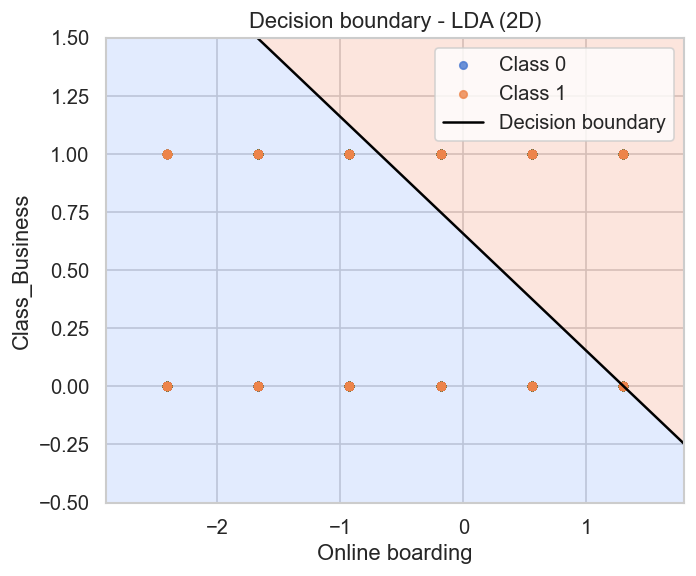

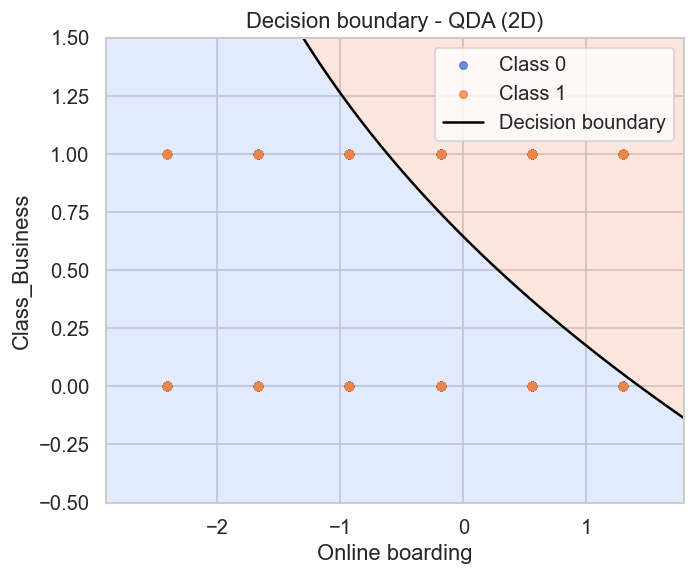

In [23]:
def plot_decision_boundary(model, X, y, title, feature_names, threshold=0.5):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    classes = np.unique(y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    zz = (proba >= threshold).astype(int)

    plt.figure(figsize=(6, 5))

    # tô nền vùng dự đoán
    plt.contourf(
        xx, yy, zz,
        levels=[-0.5, 0.5, 1.5],
        alpha=0.25,
        cmap="coolwarm"
    )

    # vẽ đường biên
    plt.contour(
        xx, yy, proba,
        levels=[threshold],
        colors="black",
        linewidths=1.5
    )

    # vẽ điểm dữ liệu từng lớp
    scatter_handles = []
    for c in classes:
        sc = plt.scatter(
            X[y == c, 0],
            X[y == c, 1],
            label=f"Class {c}",
            s=20,
            alpha=0.8
        )
        scatter_handles.append(sc)

    # tạo handle giả cho legend của decision boundary
    boundary_handle = Line2D(
        [0], [0],
        color="black",
        lw=1.5,
        label="Decision boundary"
    )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend(handles=scatter_handles + [boundary_handle])
    plt.tight_layout()
    plt.show()

plot_decision_boundary(
    lda_2d, X_test_2d, y_test,
    "Decision boundary - LDA (2D)", top2_features
)

plot_decision_boundary(
    qda_2d, X_test_2d, y_test,
    "Decision boundary - QDA (2D)", top2_features
)

**Nhận xét**:
- Mặc dù LDA tạo ra một đường biên tuyến tính rõ ràng, nhưng với hai đặc trưng được chọn, mô hình chưa phân tách tốt hai lớp. Nhiều điểm thuộc Class 1 nằm trong vùng dự đoán Class 0.
- Mô hình QDA cho phép mỗi lớp có ma trận hiệp phương sai riêng, nên đường biên quyết định có thể phi tuyến. Nhưng đường biên của QDA cũng không phân loại được chính xác.
- Điều này cho thấy cả 2 đặc trưng không đủ mạnh để phân tách lớp.

### 2.6 So sánh LDA và QDA.

LDA thường tốt hơn khi:

- **Số mẫu không quá lớn**  
   Vì LDA chỉ ước lượng **một ma trận hiệp phương sai chung**, số tham số ít hơn nên ổn định hơn.

- **Số chiều đặc trưng lớn**  
   Khi số chiều tăng, QDA phải ước lượng một ma trận hiệp phương sai cho **mỗi lớp**, dễ bị nhiễu và kém ổn định.

- **Covariance của các lớp gần giống nhau**  
   Nếu giả thiết hiệp phương sai chung là hợp lý, LDA vừa đơn giản vừa hiệu quả.

- **Cần mô hình dễ diễn giải**  
   Biên quyết định tuyến tính giúp giải thích trực quan hơn.

QDA thường tốt hơn khi:

- **Mỗi lớp có cấu trúc phương sai khác nhau rõ rệt**  
   Khi đó giả thiết của LDA bị vi phạm.

- **Biên quyết định thực sự phi tuyến**  
   QDA linh hoạt hơn do biên quyết định là bậc hai.

- **Có đủ dữ liệu để ước lượng covariance riêng cho từng lớp**  
   Khi số mẫu đủ lớn, QDA có thể tận dụng thêm độ linh hoạt để tăng hiệu năng.

Tóm lại

- **LDA**: ít tham số hơn, bền vững hơn, phù hợp khi dữ liệu vừa hoặc nhỏ và covariance giữa các lớp gần nhau.
- **QDA**: linh hoạt hơn, phù hợp khi dữ liệu đủ lớn và từng lớp có phân bố khác nhau rõ rệt.


## 3. Đánh giá mô hình

### 3.1 Huấn luyện mô hình trên toàn bộ đặc trưng và đánh giá trên tập test


In [34]:
# Hàm đánh giá classifier với các metric quan trọng
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name='Model'):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    y_pred = model.predict(X_test)
    y_proba_all = model.predict_proba(X_test)

    # xác định lớp dương cho bài toán nhị phân
    classes = np.asarray(model.classes_)
    if len(classes) != 2:
        raise ValueError("Hàm này hiện tại chỉ dùng cho bài toán nhị phân.")

    positive_class = classes[1]
    positive_idx = 1  # vì predict_proba của bạn trả theo đúng thứ tự model.classes_
    y_prob = y_proba_all[:, positive_idx]

    metrics = {
        'model': model_name,
        'positive_class': positive_class,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        'recall': recall_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        'f1': f1_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test == positive_class, y_prob),
        'log_loss': log_loss(y_test, y_proba_all, labels=classes),
        'fit_time_sec': fit_time
    }

    return metrics, y_pred, y_prob, y_proba_all

lda_full = MyLDA(reg=1e-6)
qda_full = MyQDA(reg=1e-4)

lda_metrics, y_pred_lda, y_prob_lda, y_proba_lda_all = evaluate_classifier(
    lda_full, X_train, y_train, X_test, y_test, model_name='MyLDA'
)

qda_metrics, y_pred_qda, y_prob_qda, y_proba_qda_all = evaluate_classifier(
    qda_full, X_train, y_train, X_test, y_test, model_name='MyQDA'
)

test_results_df = pd.DataFrame([lda_metrics, qda_metrics])
display(test_results_df.round(4))

,model,positive_class,accuracy,precision,recall,f1,roc_auc,avg_precision,log_loss,fit_time_sec
0,MyLDA,1,0.8690,0.8646,0.8319,0.8479,0.9252,0.9270,0.3497,0.0369
1,MyQDA,1,0.8534,0.8523,0.8057,0.8283,0.9171,0.9228,0.6506,0.0346


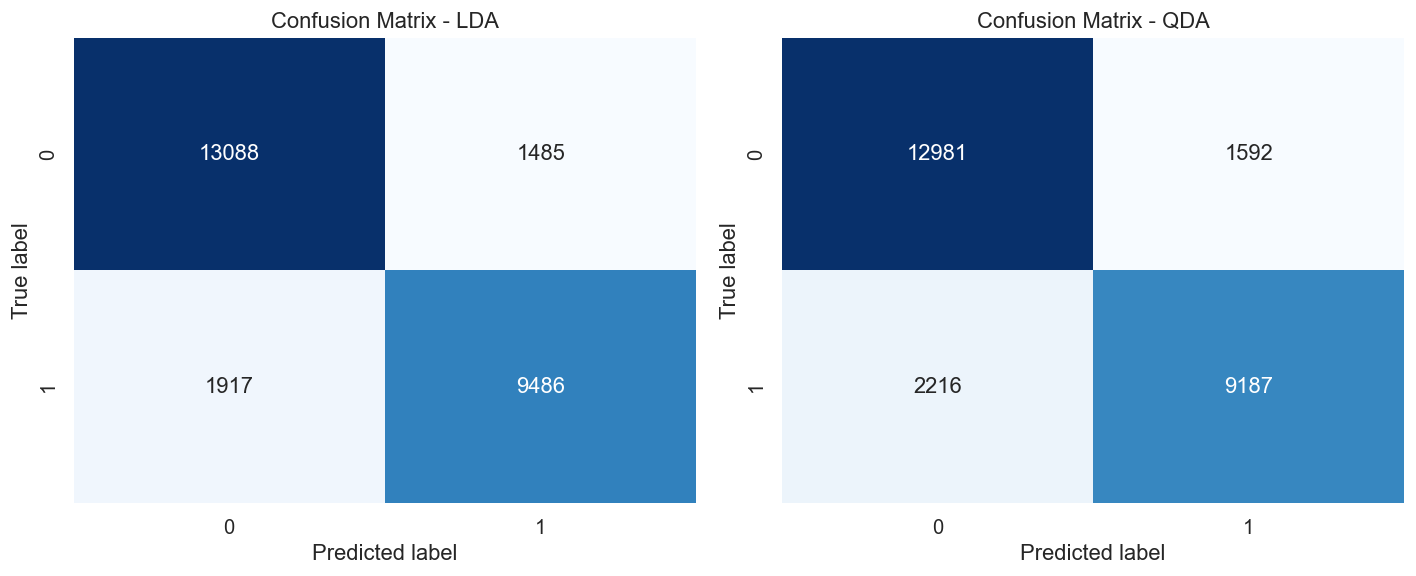

In [35]:
# Vẽ confusion matrix cho LDA và QDA
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(
    axes,
    [('LDA', y_pred_lda), ('QDA', y_pred_qda)]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax
    )
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.tight_layout()
plt.show()


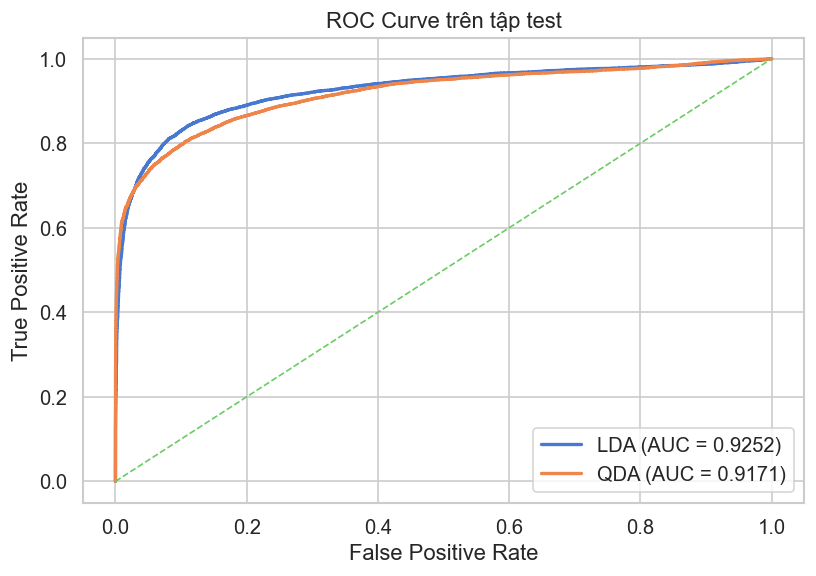

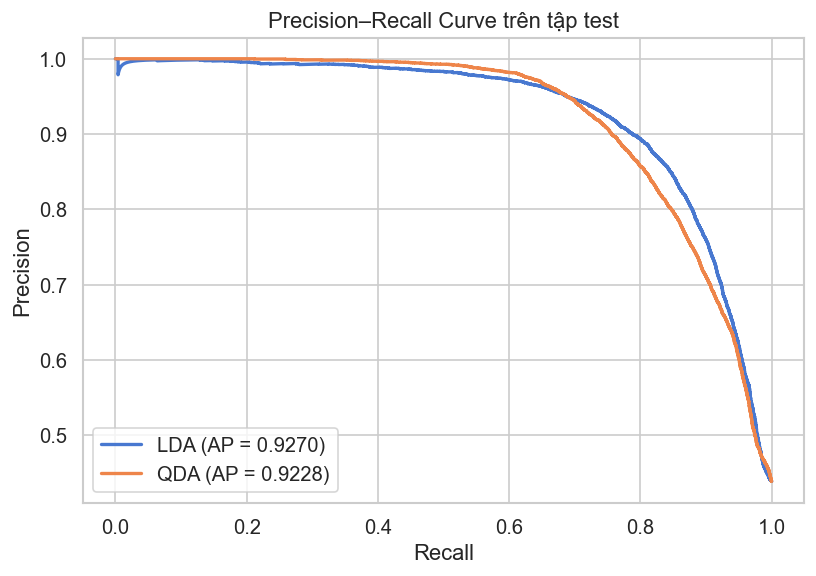

In [ ]:
# Vẽ ROC curve và Precision-Recall curve cho LDA và QDA
plt.figure(figsize=(7, 5))

for name, y_prob in [('LDA', y_prob_lda), ('QDA', y_prob_qda)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], '--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve trên tập test')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
for name, y_prob in [('LDA', y_prob_lda), ('QDA', y_prob_qda)]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, linewidth=2, label=f'{name} (AP = {ap:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve trên tập test')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# cross-validation để đánh giá ổn định của LDA và QDA
def cross_validate_model(model_class, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        model = model_class()
        model.fit(X[tr_idx], y[tr_idx])

        y_pred = model.predict(X[va_idx])
        y_prob = model.predict_proba(X[va_idx])[:, 1]

        rows.append({
            'fold': fold,
            'accuracy': accuracy_score(y[va_idx], y_pred),
            'precision': precision_score(y[va_idx], y_pred, zero_division=0),
            'recall': recall_score(y[va_idx], y_pred, zero_division=0),
            'f1': f1_score(y[va_idx], y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y[va_idx], y_prob),
            'avg_precision': average_precision_score(y[va_idx], y_prob),
            'log_loss': log_loss(y[va_idx], np.c_[1 - y_prob, y_prob], labels=[0, 1]),
        })

    return pd.DataFrame(rows)

cv_lda = cross_validate_model(MyLDA, X_train, y_train, n_splits=5)
cv_qda = cross_validate_model(MyQDA, X_train, y_train, n_splits=5)

cv_summary = pd.concat([
    cv_lda.drop(columns='fold').agg(['mean', 'std']).assign(model='LDA').reset_index().rename(columns={'index': 'stat'}),
    cv_qda.drop(columns='fold').agg(['mean', 'std']).assign(model='QDA').reset_index().rename(columns={'index': 'stat'})
], ignore_index=True)

display(cv_summary.round(4))


,stat,accuracy,precision,recall,f1,roc_auc,avg_precision,log_loss,model
0,mean,0.8719,0.8645,0.8352,0.8496,0.9262,0.9273,0.3453,LDA
1,std,0.0022,0.0033,0.0049,0.0027,0.0016,0.0014,0.0044,LDA
2,mean,0.8564,0.8552,0.8048,0.8292,0.9197,0.9245,0.6273,QDA
3,std,0.0021,0.0029,0.0040,0.0026,0.0017,0.0018,0.0118,QDA


In [ ]:
# Hàm thực hiện McNemar's test để so sánh 2 classifier trên cùng tập test
def mcnemar_test(y_true, pred_a, pred_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    b = np.sum(correct_a & ~correct_b)  # A đúng, B sai
    c = np.sum(~correct_a & correct_b)  # A sai, B đúng

    stat = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0.0
    p_value = binomtest(min(b, c), n=b + c, p=0.5, alternative='two-sided').pvalue if (b + c) > 0 else 1.0

    return {
        'b_LDA_correct_QDA_wrong': int(b),
        'c_LDA_wrong_QDA_correct': int(c),
        'chi2_approx': stat,
        'p_value_exact': p_value
    }

mcnemar_result = pd.DataFrame([mcnemar_test(y_test, y_pred_lda, y_pred_qda)])
display(mcnemar_result.round(6))


,b_LDA_correct_QDA_wrong,c_LDA_wrong_QDA_correct,chi2_approx,p_value_exact
0,1179,773,84.029201,0.0


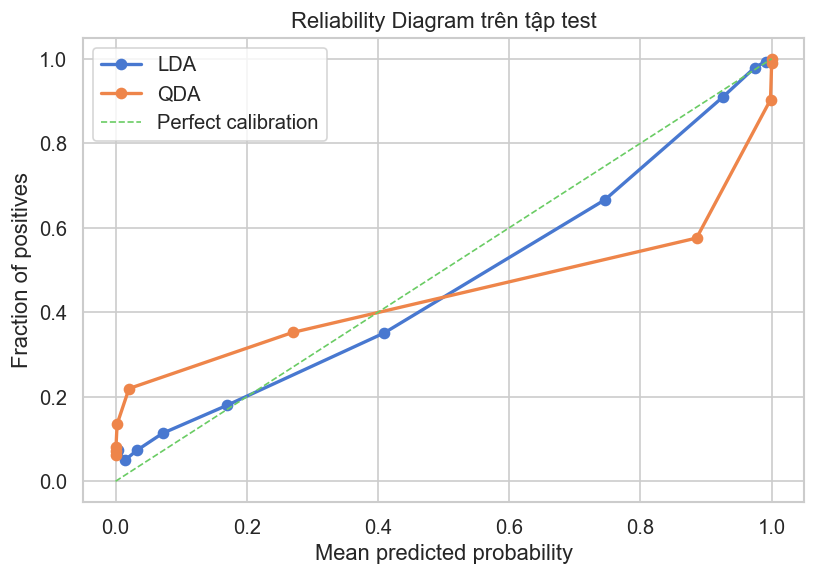

In [ ]:
# Vẽ reliability diagram (calibration curve) cho LDA và QDA
plt.figure(figsize=(7, 5))

for name, y_prob in [('LDA', y_prob_lda), ('QDA', y_prob_qda)]:
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', linewidth=2, label=name)

plt.plot([0, 1], [0, 1], '--', linewidth=1, label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability Diagram trên tập test')
plt.legend()
plt.tight_layout()
plt.show()


- Lưu kết quả 

In [ ]:
os.makedirs(PROC_DATA_PATH, exist_ok=True)

save_models = {
    "LDA": {
        "model": lda_full,
        "model_name": "MyLDA",
        "metrics": lda_metrics,
        "y_pred": y_pred_lda,
        "y_prob": y_prob_lda
    },
    "QDA": {
        "model": qda_full,
        "model_name": "MyQDA",
        "metrics": qda_metrics,
        "y_pred": y_pred_qda,
        "y_prob": y_prob_qda
    }
}

MODEL_PATH = os.path.join(PROC_DATA_PATH, "lda_qda_models.pkl")

with open(MODEL_PATH, "wb") as f:
    pickle.dump(save_models, f)

print(f"Đã lưu model tại: {MODEL_PATH}")

### 3.2 Nhận xét kết quả đánh giá

- **LDA cho kết quả tốt hơn QDA** trên toàn bộ đặc trưng ở cả **Accuracy, F1, ROC-AUC và AP**.
- **QDA yếu hơn** trong bài toán này vì phải ước lượng **một ma trận hiệp phương sai riêng cho mỗi lớp**, nên số tham số nhiều hơn và nhạy hơn với nhiễu.
- Kết quả này phù hợp với lý thuyết: khi dữ liệu có số chiều tương đối lớn và cấu trúc covariance giữa các lớp không khác nhau quá mạnh, **LDA thường ổn định hơn QDA**.
- **McNemar’s test** cho biết sự khác biệt dự đoán giữa hai mô hình trên cùng tập test là có hay không có ý nghĩa thống kê. Nếu `p_value < 0.05`, có thể kết luận chênh lệch là **có ý nghĩa thống kê**.
- **Reliability diagram** cho phép đánh giá chất lượng xác suất đầu ra: đường càng gần đường chéo thì mô hình càng được **calibrate** tốt.


Có thể tóm tắt phần thảo luận như sau:

- **LDA phù hợp hơn** khi:
  - số mẫu không quá lớn so với số chiều,
  - cần mô hình ổn định và dễ diễn giải,
  - giả thiết covariance giữa các lớp là gần nhau.

- **QDA phù hợp hơn** khi:
  - mỗi lớp thực sự có **cấu trúc phương sai–hiệp phương sai khác nhau**,
  - có đủ nhiều dữ liệu để ước lượng covariance riêng cho từng lớp,
  - decision boundary tuyến tính của LDA là quá đơn giản.

Trong bộ dữ liệu hiện tại, **LDA là lựa chọn tốt hơn QDA** vì đạt hiệu năng cao hơn và calibration cũng ổn định hơn.